# Uncertainty

Every CLERO prediction comes with an uncertainty. We show three uses: (a) the uncertainty on a quantity derived from the climate, via samples; (b) how to summarize humidity and other skewed fields; (c) how uncertainty grows outside the core domain.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from clero import Emulator
from clero.climate_analysis import global_mean, latitude_centers, latitude_weights

emu = Emulator()
INPUTS = {
    "T_star": 3000.0, "F_star": 1000.0, "radius": 1.0, "gravity": 9.8,
    "P_rot": 10.0, "P0": 1.0, "CO2": 4.0e-4, "CH4": 0.0, "GCM": "um",
}

## (a) Uncertainty on a derived quantity

Each sample is a complete climate, so any quantity computed from one climate can be computed from every sample; the spread across samples is its uncertainty. Here the quantity is the area-weighted global-mean surface temperature.

global-mean surface T: 242.28 ± 5.90 K


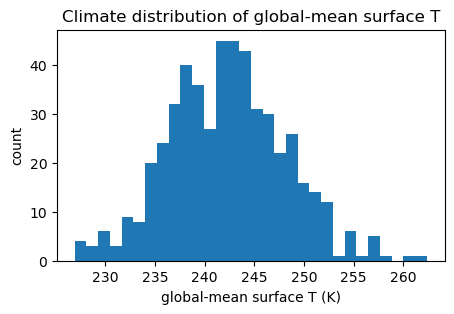

In [6]:
# This linear temperature average also has an analytic Gaussian distribution; sampling works for nonlinear diagnostics too.
samples = emu.sample(INPUTS, n_samples=512, seed=0)
lat = latitude_centers(samples["surface_temperature"].shape[1])
gm = np.array([global_mean(s, lat) for s in samples["surface_temperature"]])
print(f"global-mean surface T: {gm.mean():.2f} ± {gm.std(ddof=1):.2f} K")

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(gm, bins=30)
ax.set(xlabel="global-mean surface T (K)", ylabel="count", title="Climate distribution of global-mean surface T")
plt.show()

## (b) Summarizing skewed fields in model space

Specific humidity and cloud fraction are strongly skewed in physical units, and a physical-space mean ± standard deviation implies negative values. We instead sample in model space, where the distribution is closer to Gaussian, summarize there, and map the summary back with `to_physical`. Quantiles are preserved by the mapping, so the result is a physical median with an asymmetric interval.

In [7]:
field = "specific_humidity_5"
draws = emu.sample(INPUTS, n_samples=256, seed=0, space="model")[field]
mu, sd = draws.mean(0), draws.std(0, ddof=1)
band = emu.to_physical(field, np.stack([mu - sd, mu, mu + sd]), INPUTS)
lo, med, hi = (float(b.mean()) for b in band)
print(f"via model space  16/50/84: {lo:.2e} / {med:.2e} / {hi:.2e}  (asymmetric, all > 0)")

naive = emu.sample(INPUTS, n_samples=256, seed=0)[field]
print(f"naive physical   mean±std: {naive.mean():.2e} ± {naive.std():.2e}  (std implies negatives!)")

via model space  16/50/84: 8.89e-05 / 1.85e-04 / 3.86e-04  (asymmetric, all > 0)
naive physical   mean±std: 2.41e-04 ± 4.69e-04  (std implies negatives!)


## (c) Uncertainty grows outside the core domain

Predictive uncertainty widens as inputs move away from the training simulations. Sweeping instellation across the extended domain, the per-cell standard deviation of surface temperature (from `return_variance`, averaged over the map) rises on either side of the core domain (500–1500 W/m²). 

Note: these curves are per-cell uncertainties averaged over the map. They are not the uncertainty of the global mean, which depends on how errors in different cells are correlated and must be computed from samples; see `using_clero_samples.ipynb`.

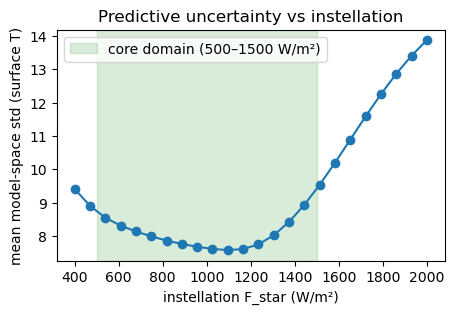

In [9]:
fluxes = np.linspace(400.0, 2000.0, 24)  # stays inside the extended domain (400–3100 W/m²)
n = fluxes.size
base = dict(T_star=3000.0, radius=1.0, gravity=9.8, P_rot=10.0, P0=1.0, CO2=4.0e-4, CH4=0.0)
batch = {key: np.full(n, value) for key, value in base.items()}
batch["F_star"] = fluxes
batch["GCM"] = ["um"] * n

_, var = emu.predict(batch, space="model", return_variance=True)
lat = latitude_centers(var["surface_temperature"].shape[1])
w = latitude_weights(lat)
mean_std = (np.sqrt(var["surface_temperature"]).mean(axis=2) * w[None]).sum(axis=1)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(fluxes, mean_std, marker="o")
ax.axvspan(500.0, 1500.0, alpha=0.15, color="green", label="core domain (500–1500 W/m²)")
ax.set(xlabel="instellation F_star (W/m²)", ylabel="mean model-space std (surface T)", title="Predictive uncertainty vs instellation")
ax.legend()
plt.show()